In [45]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

### Figure 4G

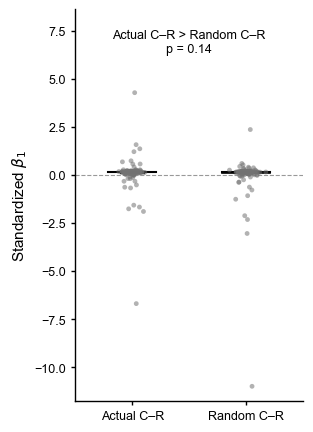

In [50]:
# 1. Data
df_receptor_coefficients=pd.read_csv("/data/kumarr17/figures_to_upload/supplementray_table/df_receptor_coefficients.csv",index_col='Unnamed: 0')
actual = np.asarray(list(df_receptor_coefficients['real']), dtype=float)
random = np.asarray(list(df_receptor_coefficients['random']), dtype=float)

# Remove NaN and infinite values
actual = actual[np.isfinite(actual)]
random = random[np.isfinite(random)]

# ============================================================
# 2. Normalize relative to RANDOM C-R distribution
# ============================================================

random_mean = np.mean(random)
random_sd = np.std(random, ddof=1)

actual_z = (actual - random_mean) / random_sd
random_z = (random - random_mean) / random_sd

# ============================================================
# 3. One-sided Mann-Whitney U test
#
# H0: Actual C-R is not greater than Random C-R
# H1: Actual C-R > Random C-R
# ============================================================

stat, pval = mannwhitneyu(
    actual_z,
    random_z,
    alternative="greater"
)

# ============================================================
# 4. Publication settings
# ============================================================

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 9,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,

    # Keep text editable in SVG
    "svg.fonttype": "none"
})


# ============================================================
# 5. Create figure
# ============================================================

fig, ax = plt.subplots(figsize=(3.2, 4.4))

positions = [1, 2]


# ============================================================
# 6. Boxplot
# ============================================================

ax.boxplot(
    [actual_z, random_z],
    positions=positions,
    widths=0.42,
    patch_artist=True,
    showfliers=False,

    medianprops=dict(
        color="black",
        linewidth=1.5
    ),

    boxprops=dict(
        facecolor="white",
        edgecolor="black",
        linewidth=1.2
    ),

    whiskerprops=dict(
        color="black",
        linewidth=1.0
    ),

    capprops=dict(
        color="black",
        linewidth=1.0
    )
)


# ============================================================
# 7. Individual observations
# ============================================================

# Reproducible jitter
np.random.seed(42)

jitter = 0.045

x_actual = np.random.normal(
    loc=1,
    scale=jitter,
    size=len(actual_z)
)

x_random = np.random.normal(
    loc=2,
    scale=jitter,
    size=len(random_z)
)

# Actual C-R
ax.scatter(
    x_actual,
    actual_z,
    s=12,
    color="0.45",
    alpha=0.55,
    edgecolors="none",
    zorder=3
)

# Random C-R
ax.scatter(
    x_random,
    random_z,
    s=12,
    color="0.45",
    alpha=0.55,
    edgecolors="none",
    zorder=3
)


# ============================================================
# 8. Zero reference line
#
# Zero = mean of random C-R beta distribution
# ============================================================

ax.axhline(
    y=0,
    color="0.6",
    linestyle="--",
    linewidth=0.8,
    zorder=0
)


# ============================================================
# 9. Statistical annotation
# ============================================================

data_max = max(
    np.max(actual_z),
    np.max(random_z)
)

data_min = min(
    np.min(actual_z),
    np.min(random_z)
)

data_range = data_max - data_min

# ============================================================
# 10. Format p-value
# ============================================================

if pval < 0.0001:
    p_text = "p < 0.0001"

elif pval < 0.001:
    p_text = f"p = {pval:.4f}"

elif pval < 0.01:
    p_text = f"p = {pval:.3f}"

else:
    p_text = f"p = {pval:.2f}"


# ============================================================
# 11. Add hypothesis + p-value
# ============================================================

ax.text(
    1.5,
    y + h + 0.025 * data_range,

    f"Actual C–R > Random C–R\n{p_text}",

    ha="center",
    va="bottom",
    fontsize=9
)


# ============================================================
# 12. Axis formatting
# ============================================================

ax.set_xticks(positions)

ax.set_xticklabels(
    ["Actual C–R", "Random C–R"],
    fontsize=9
)

ax.set_ylabel(
    r"Standardized $\beta_1$",
    fontsize=11
)

ax.set_xlabel("")


# ============================================================
# 13. Y-axis limits
# ============================================================

ax.set_ylim(
    data_min - 0.05 * data_range,
    y + h + 0.18 * data_range
)


# ============================================================
# 14. Clean figure axes
# ============================================================

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.spines["left"].set_linewidth(1)
ax.spines["bottom"].set_linewidth(1)

ax.tick_params(
    axis="both",
    labelsize=9,
    width=1,
    length=3
)

ax.grid(False)

plt.tight_layout()


# ============================================================
# 15. Save Figure vector SVG
# ============================================================

#output_file = (
#    "/data/kumarr17/figures_to_upload/Figure3/"
#    "actual_vs_random_CR_standardized_beta.svg"
#)

#fig.savefig(
#    output_file,
#    format="svg",
#    bbox_inches="tight",
#    transparent=False
#)

#plt.show()

#print(f"\nSaved figure:\n{output_file}")